In [2]:
import os
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import json


In [3]:
os.chdir("..")

In [4]:
STATS_PATH = "data/mileage_stats.json"
with open(STATS_PATH, 'r') as f:
    stats = json.load(f)
    
global_mean_mileage = float(stats['mean_mileage'])
global_std_mileage = float(stats['std_mileage'])

# Calculate priors
# We use the log of the global mean as the center for the prior
prior_mu = np.log(global_mean_mileage)
# We use the log of the global SD as the center for the shape parameter (sigma)
prior_sigma = np.log(global_std_mileage) 

In [5]:
columns_needed = [
    'make', 'model', 'fuelType', 'engineSize_bucket', 
    'defect_count_advisory', 'defect_count_dangerous', 
    'mileage_estimate',
    'event_interval'
]
df = pd.read_parquet('data/mot_last_test.parquet', columns=columns_needed).head(50000)

In [6]:
# 3. Preprocessing data
# --- code categorical variables for pymc ---
df['make_id'] = df['make'].astype('category').cat.codes
df['model_id'] = df['model'].astype('category').cat.codes
df['fuel_id'] = df['fuelType'].astype('category').cat.codes
df['engine_id'] = df['engineSize_bucket'].astype('category').cat.codes

# --- Continuous (Using Fixed Stats) ---
#df['mileage_std'] = (df['mileage_estimate'] - mean_mileage) / std_mileage
df['log_mileage'] = np.log(df['mileage_estimate'])


In [7]:
make_ids = df['make_id'].values
model_ids = df['model_id'].values
engine_ids = df['engine_id'].values
fuel_ids = df['fuel_id'].values
defect_advisory = df['defect_count_advisory'].values
defect_dangerous = df['defect_count_dangerous'].values
#log_time = df['log_time'].values
log_mileage = df['log_mileage'].values
event_interval = df['event_interval'].values

In [ ]:
y = np.log(df['mileage_estimate'].values)
event = np.asarray(event_interval)

with pm.Model(coords={
    "make_id": np.arange(df['make'].nunique()),
    "model_id": np.arange(df['model'].nunique()),
    "engine_id": np.arange(df['engineSize_bucket'].nunique()),
    "fuel_id": np.arange(df['fuelType'].nunique())
}) as hierarchical_weibull:

    # Global intercept & scale parameter
    mu_global = pm.Normal('mu_global', mu=float(prior_mu), sigma=0.5)
    sigma_global = pm.HalfNormal('sigma_global', sigma=prior_sigma)

    # Hierarchical scale hyperpriors to pool group variations
    sigma_make = pm.HalfStudentT('sigma_make', nu=3, sigma=2.5)
    sigma_model = pm.HalfStudentT('sigma_model', nu=3, sigma=2.5)
    sigma_engine = pm.HalfStudentT('sigma_engine', nu=3, sigma=2.5)
    sigma_fuel = pm.HalfStudentT('sigma_fuel', nu=3, sigma=2.5)

    # Effects (Non-centered parameterization for stable sampling)
    make_raw = pm.Normal('make_raw', mu=0, sigma=1, dims='make_id')
    model_raw = pm.Normal('model_raw', mu=0, sigma=1, dims='model_id')
    engine_raw = pm.Normal('engine_raw', mu=0, sigma=1, dims='engine_id')
    fuel_raw = pm.Normal('fuel_raw', mu=0, sigma=1, dims='fuel_id')

    make_effect = pm.Deterministic('make_effect', make_raw * sigma_make, dims='make_id')
    model_effect = pm.Deterministic('model_effect', model_raw * sigma_model, dims='model_id')
    engine_effect = pm.Deterministic('engine_effect', engine_raw * sigma_engine, dims='engine_id')
    fuel_effect = pm.Deterministic('fuel_effect', fuel_raw * sigma_fuel, dims='fuel_id')
    
    beta_advisory = pm.Normal('beta_advisory', mu=0, sigma=1)
    beta_dangerous = pm.Normal('beta_dangerous', mu=0, sigma=1)

    # Linear Predictor
    mu = (
        mu_global 
        + make_effect[make_ids] 
        + model_effect[model_ids] 
        + engine_effect[engine_ids] 
        + fuel_effect[fuel_ids]
        + beta_advisory * defect_advisory   
        + beta_dangerous * defect_dangerous     
    )

    # Standardized residual: z = (log(T) - mu) / sigma
    z = (y - mu) / sigma_global

    # Correct Log-Weibull Likelihood:
    # Event (uncensored): log(f(y)) = -log(sigma) + z - exp(z)
    # Censored:           log(S(y)) = -exp(z)
    log_lik_obs = -pm.math.log(sigma_global) + z - pm.math.exp(z)
    log_lik_cens = -pm.math.exp(z)

    log_lik = pm.math.switch(pm.math.eq(event, 1), log_lik_obs, log_lik_cens)

    # Sum across all observations
    pm.Potential('mileage_likelihood', pm.math.sum(log_lik))

    trace = pm.sample(2000, tune=1000,nuts_sampler="numpyro", target_accept=0.95, random_seed=42)

C:\DataScience\Portfolio\UK Car Analyser\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

In [10]:
# Check divergences
div_count = sum(trace.posterior.attrs.get('diverging', [0]))
print(f"Divergent transitions: {div_count} / {trace.posterior.dims['draw'] * trace.posterior.dims['chain']}")

# If > 10% divergent, the model is still problematic — consider dropping model level
if div_count / (2000 * 4) > 0.1:
    print("WARNING: >10% divergences. Consider dropping the model-level hierarchy.")

# Check R-hat
rhat = az.rhat(trace.posterior, var_names=['mu_global', 'sigma_global', 'sigma_make', 'sigma_model', 'beta_advisory', 'beta_dangerous'])
print(rhat)

# Check ESS
ess = az.ess(trace.posterior, var_names=['mu_global', 'sigma_global', 'sigma_make', 'sigma_model'])
print(ess)

# Check effective sample size per parameter — low ESS on sigma_hyperpriors means poor mixing
print("\nEffective Sample Size:")
print(ess)

Divergent transitions: 0 / 8000
<xarray.Dataset> Size: 48B
Dimensions:         ()
Data variables:
    mu_global       float64 8B 1.522
    sigma_global    float64 8B 1.525
    sigma_make      float64 8B 1.527
    sigma_model     float64 8B 1.262
    beta_advisory   float64 8B 1.524
    beta_dangerous  float64 8B 1.524
Attributes:
    created_at:                 2026-09-02T21:53:19.573169+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5
    sampling_time:              2897.012773513794
    tuning_steps:               1000
<xarray.Dataset> Size: 32B
Dimensions:       ()
Data variables:
    mu_global     float64 8B 7.286
    sigma_global  float64 8B 7.164
    sigma_make    float64 8B 7.239
    sigma_model   float64 8B 11.94
Attributes:
    created_at:                 2026-09-02T21:53:19.573169+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5
    s

C:\Users\Grum\AppData\Local\Temp\ipykernel_20536\3429849483.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Divergent transitions: {div_count} / {trace.posterior.dims['draw'] * trace.posterior.dims['chain']}")


In [8]:
vars_to_check = [
    'mu_global', 'sigma_global', 
    'make_effect', 'model_effect', 'engine_effect', 'fuel_effect',
    'beta_advisory', 'beta_dangerous'
]
print("Available variables in trace:", list(trace.posterior.data_vars))



rhat = az.rhat(trace.posterior, var_names=vars_to_check)
print(rhat)


Available variables in trace: ['mu_global', 'make_raw', 'model_raw', 'engine_raw', 'fuel_raw', 'beta_advisory', 'beta_dangerous', 'sigma_global', 'sigma_make', 'sigma_model', 'sigma_engine', 'sigma_fuel', 'make_effect', 'model_effect', 'engine_effect', 'fuel_effect']
<xarray.Dataset> Size: 51kB
Dimensions:         (make_id: 156, model_id: 3029, engine_id: 14, fuel_id: 5)
Coordinates:
  * make_id         (make_id) int64 1kB 0 1 2 3 4 5 ... 150 151 152 153 154 155
  * model_id        (model_id) int64 24kB 0 1 2 3 4 ... 3024 3025 3026 3027 3028
  * engine_id       (engine_id) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
  * fuel_id         (fuel_id) int64 40B 0 1 2 3 4
Data variables:
    mu_global       float64 8B 1.522
    sigma_global    float64 8B 1.525
    make_effect     (make_id) float64 1kB 1.525 1.379 1.184 ... 1.526 1.517
    model_effect    (model_id) float64 24kB 1.471 1.526 1.322 ... 1.062 1.253
    engine_effect   (engine_id) float64 112B 1.526 1.526 1.525 ... 1.221 1.524
    

In [9]:
# Calculate the mean and SD of the posterior
posterior_stats = trace.posterior.mean(dim=['chain', 'draw'])
print("Posterior Means:")
print(posterior_stats[['mu_global', 'sigma_global', 'beta_advisory', 'beta_dangerous']])

# Check the SD for the hierarchical effects
print("\nMake Effect Mean (should vary):")
print(posterior_stats['make_effect'])

Posterior Means:
<xarray.Dataset> Size: 32B
Dimensions:         ()
Data variables:
    mu_global       float64 8B 11.53
    sigma_global    float64 8B 0.314
    beta_advisory   float64 8B -0.03862
    beta_dangerous  float64 8B -0.04037
Attributes:
    created_at:                 2026-09-02T21:53:19.573169+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5
    sampling_time:              2897.012773513794
    tuning_steps:               1000

Make Effect Mean (should vary):
<xarray.DataArray 'make_effect' (make_id: 156)> Size: 1kB
array([ 0.09521061,  0.1782153 ,  0.31885044,  0.33757552,  0.111096  ,
       -0.53186026, -1.37150723, -0.19903909,  0.51399937, -0.02877951,
        0.1223833 ,  0.44533924,  0.0595728 ,  0.44079228,  0.26393774,
        0.6382005 , -1.30391616, -0.30198456,  0.38574675,  0.03621814,
        0.05990891, -0.26297796, -0.04945532, -0.10773739,  0.36709021,
        0.12131646,  0.17715352, 

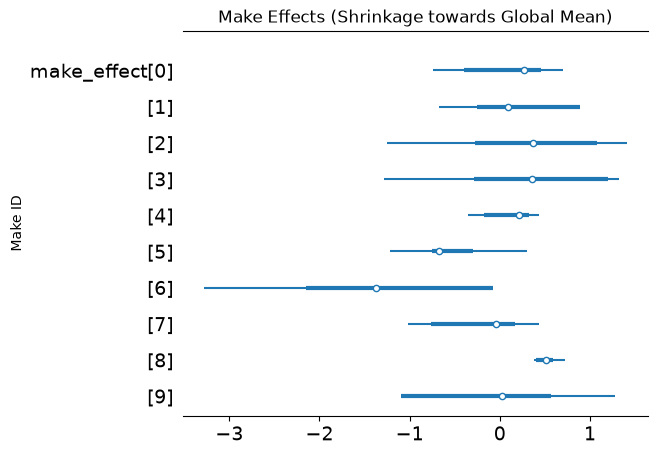

In [11]:
# 1. Plot the Make Effects (Forest Plot)
# This shows how much each Make deviates from the Global Mean
az.plot_forest(trace, var_names=['make_effect'], kind='forestplot', combined=True,
               coords={'make_id': range(10)}) # Show first 10 makes for clarity
plt.title('Make Effects (Shrinkage towards Global Mean)')
plt.ylabel('Make ID')
plt.show()


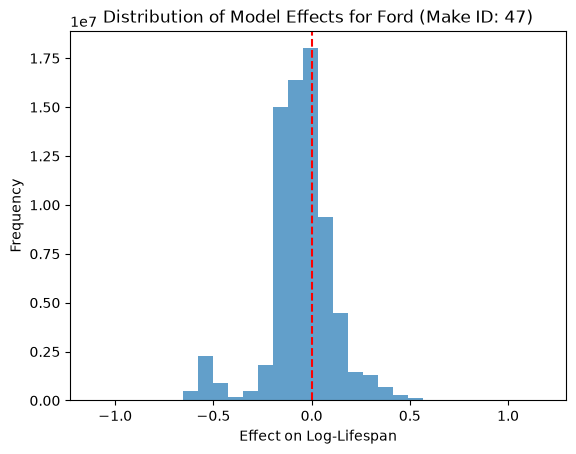

In [12]:

# 2. Plot the Model Effects for a specific Make (e.g., Ford)
# You need to find the Make ID for Ford first
ford_make_id = df[df['make'] == 'FORD']['make_id'].iloc[0]

# Filter the posterior for Ford's models
ford_model_effects = trace.posterior['model_effect'].sel(model_id=df[df['make']=='FORD']['model_id'].values)

# Plot histogram of Ford's models
ford_model_effects.plot.hist(bins=30, alpha=0.7)
plt.title(f'Distribution of Model Effects for Ford (Make ID: {ford_make_id})')
plt.xlabel('Effect on Log-Lifespan')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--') # Show global mean
plt.show()

In [43]:
print(df['make'].unique())

['SKODA' 'VOLKSWAGEN' 'MITSUBISHI' 'MAZDA' 'VAUXHALL' 'TOYOTA' 'FORD'
 'MERCEDES-BENZ' 'NISSAN' 'HONDA' 'LAND ROVER' 'PEUGEOT' 'HARLEY DAVIDSON'
 'BENTLEY' 'BMW' 'LAMBORGHINI' 'PORSCHE' 'KIA' 'MINI' 'FERRARI' 'AUDI'
 'ABARTH' 'LEXUS' 'SMART (MCC)' 'ALFA ROMEO' 'VOLVO' 'ASTON MARTIN'
 'MERCEDES' 'RENAULT' 'JEEP' 'ROLLS ROYCE' 'MCLAREN' 'CITROEN' 'JAGUAR'
 'SEAT' 'TESLA' 'CADILLAC' 'LAMBO' 'FIAT' 'HYUNDAI' 'SUZUKI' 'DACIA'
 'WESTFIELD ELEVEN' 'ROVER' 'SUBARU' 'SAAB' 'MAN' 'DAIMLER' 'ISUZU'
 'IVECO' 'CHEVROLET' 'OPEL' 'MG' 'CARVER CARGO' 'MASERATI' 'SSANGYONG'
 'SMART' 'LOTUS' 'CHRYSLER' 'BUELL' 'DODGE' 'LDV' 'AUTO-SLEEPERS'
 'DAIHATSU' 'CHRYSLER-JEEP' 'HARLEY-DAVIDSON' 'YAMAHA' 'PROTON' 'KAWASAKI'
 'MOTO GUZZI' 'PERODUA' 'TRIUMPH' 'DS' 'PONTIAC' 'GENERAL MOTORS'
 'INFINITI' 'KTM' 'REWACO' 'APRILIA' 'DUCATI' 'CUPRA' 'TALBOT' 'CAN-AM'
 'VOLKSWAGEN GOLF TREND FSI 1.6L' 'DAEWOO' 'DUCATO CARTHAGO 150' 'DFSK'
 'CHEVROLET GMC' 'MERCURY' 'SCION' 'GREAT WALL' 'PIAGGIO' 'RENAULT TRUCKS'
 'MORGAN' 

In [13]:
# Save the PyMC trace to a NetCDF file
trace.to_netcdf('data/bayes_weib_hier_surv_model_trace.nc')
print("Model trace saved to model_trace.nc")


Model trace saved to model_trace.nc


In [29]:
print(df['mileage_estimate'].mean())

99009.91700836785
